<a href="https://colab.research.google.com/github/xMohammadAsimx/Cybersecurity-Risk-Assessment-MSHS/blob/main/Arabic_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Install & Import Libraries

In [ ]:
# Install necessary libraries and import them
!pip install tensorflow pandas numpy matplotlib --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


### Load the Data

In [ ]:
# Load the Arabic MNIST dataset from CSV files
X_train = pd.read_csv('/content/drive/MyDrive/ArabicMNIST/Dataset/csvTrainImages 60k x 784.csv').values
Y_train = pd.read_csv('/content/drive/MyDrive/ArabicMNIST/Dataset/csvTrainLabel 60k x 1.csv').values
X_test = pd.read_csv('/content/drive/MyDrive/ArabicMNIST/Dataset/csvTestImages 10k x 784.csv').values
Y_test = pd.read_csv('/content/drive/MyDrive/ArabicMNIST/Dataset/csvTestLabel 10k x 1.csv').values

print("Shapes:")
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)


Shapes:
X_train: (59999, 784)
Y_train: (59999, 1)
X_test: (9999, 784)
Y_test: (9999, 1)


### Preprocess the Data for CNN

In [ ]:
# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape images to 28x28x1 for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Convert labels to one-hot encoding
Y_train = to_categorical(Y_train, num_classes=10)
Y_test = to_categorical(Y_test, num_classes=10)

# Split validation set
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=42)

print("After preprocessing:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


After preprocessing:
X_train: (53999, 28, 28, 1)
X_val: (6000, 28, 28, 1)
X_test: (9999, 28, 28, 1)


### Visualize Sample Images

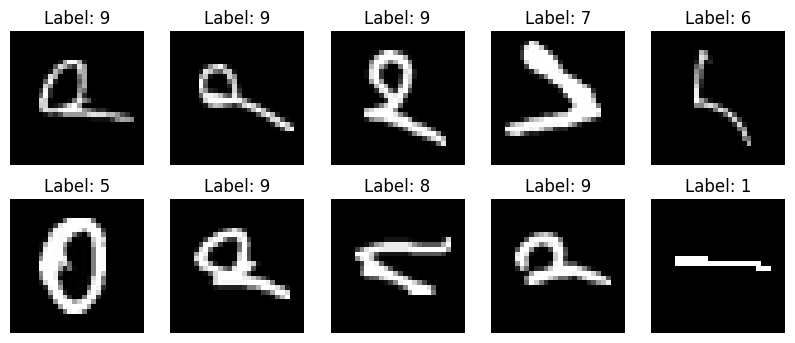

In [ ]:
# Display some Arabic MNIST digits
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {np.argmax(Y_train[i])}")
    plt.axis('off')
plt.show()


### Define the CNN Model

In [ ]:
# Define a Convolutional Neural Network
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Train the CNN


In [ ]:
# Train the CNN
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=25,
    batch_size=128
)


Epoch 1/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8592 - loss: 0.4730 - val_accuracy: 0.9912 - val_loss: 0.0310
Epoch 2/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9859 - loss: 0.0517 - val_accuracy: 0.9932 - val_loss: 0.0240
Epoch 3/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9898 - loss: 0.0385 - val_accuracy: 0.9947 - val_loss: 0.0196
Epoch 4/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9901 - loss: 0.0333 - val_accuracy: 0.9952 - val_loss: 0.0186
Epoch 5/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9922 - loss: 0.0272 - val_accuracy: 0.9935 - val_loss: 0.0213
Epoch 6/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9923 - loss: 0.0274 - val_accuracy: 0.9957 - val_loss: 0.0155
Epoch 7/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9930 - loss: 0.0219 - val_accuracy: 0.9955 - val_loss: 0.0171
Epoch 8/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9936 - loss: 0.0213 - val_accuracy: 

### Evaluate on Test Set

In [ ]:
# Evaluate CNN performance on test data
test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9929 - loss: 0.0370
Test Accuracy: 99.30%


### Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


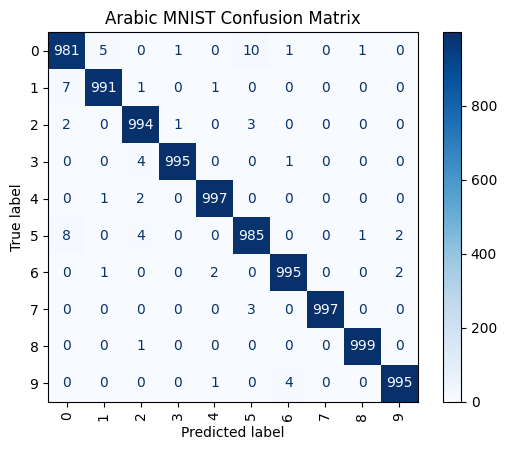

In [ ]:
# Convert one-hot labels back to integers
y_true = np.argmax(Y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# define class names for Arabic digits 0-9
class_names = [str(i) for i in range(10)]

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Arabic MNIST Confusion Matrix")
plt.show()


### Plot Training History

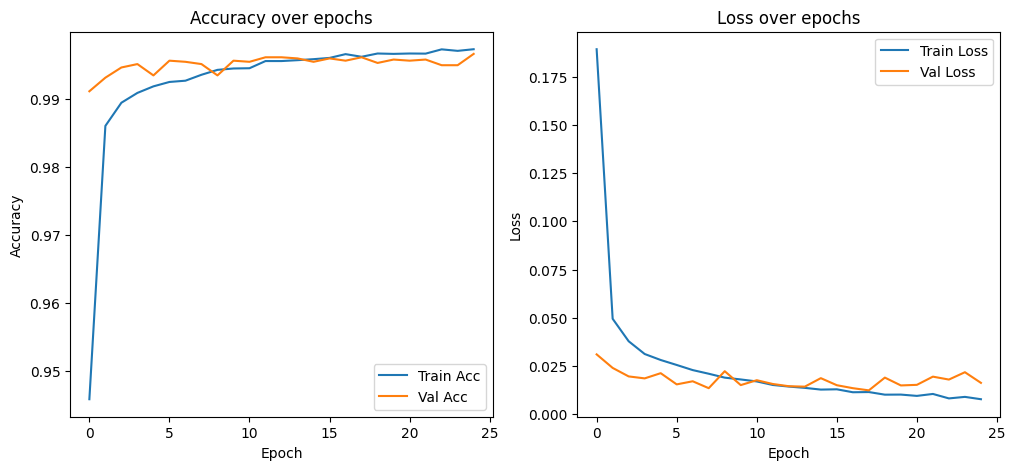

In [ ]:
# Visualize training and validation accuracy/loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()
